# Practice 3: Customer Clustering - Bước 3: Làm sạch dữ liệu (Data Cleaning)

---

## 1. Import các thư viện và cấu hình trực quan hóa

Chúng ta import các thư viện thao tác dữ liệu (`pandas`, `numpy`) và các thư viện đồ họa (`matplotlib`, `seaborn`) để hỗ trợ việc phân tích trực quan.

In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình vẽ đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")

train_df = pd.read_csv("../data/raw/Train.csv")

print(f"Kích thước dữ liệu ban đầu:")
print(f"  - Tập Train: {train_df.shape}")

Kích thước dữ liệu ban đầu:
  - Tập Train: (8068, 11)


## 2. Loại bỏ các dòng trùng lặp (Duplicates)

Trước khi phân tích sâu hơn, ta tiến hành loại bỏ các mẫu trùng lặp hoàn toàn hoặc trùng lặp mã định danh `ID`.

In [16]:
# Loại bỏ dòng trùng lặp hoàn toàn
train_df = train_df.drop_duplicates()

# Loại bỏ trùng lặp ID (giữ lại dòng đầu tiên)
train_df = train_df.drop_duplicates(subset=['ID'], keep='first')

print(f"Sau khi xóa trùng lặp - Train: {train_df.shape}")

Sau khi xóa trùng lặp - Train: (8068, 11)


### 6.1. Loại bỏ các giá trị mâu thuẫn logic (Sanity Outliers Cleaning)

Để đảm bảo tính trung thực thống kê và độ tin cậy cao nhất cho mô hình phân cụm, chúng ta tiến hành loại bỏ các mẫu dữ liệu lỗi logic nghiêm trọng không thể tự ý khôi phục:
1. **Mâu thuẫn Độ tuổi và Kinh nghiệm:** Loại bỏ các trường hợp `Age - Work_Experience < 15` (đi làm trước 15 tuổi).
2. **Mâu thuẫn Nghề nghiệp và Trình độ học vấn:** Loại bỏ các trường hợp nghề nghiệp là Bác sĩ (`Doctor`) hoặc Luật sư (`Lawyer`) nhưng có nhãn chưa tốt nghiệp (`Graduated == 'No'`). Do việc tự ý điều chỉnh nhãn là thiếu căn cứ thực tế từ nguồn dữ liệu gốc, việc loại bỏ hoàn toàn các mẫu lỗi này là phương án tối ưu để có tập dữ liệu Train sạch tinh khiết.

In [17]:
# Thống kê kích thước trước khi lọc
size_before = train_df.shape[0]

# 1. Xác định các bản ghi thực sự vi phạm logic (bỏ qua NaN để xử lý điền khuyết sau)
mask_anomaly_age = (train_df['Age'] - train_df['Work_Experience'] < 15)
mask_anomaly_prof = (train_df['Profession'].isin(['Doctor', 'Lawyer'])) & (train_df['Graduated'] == 'No')

# 2. Loại bỏ các bản ghi thực sự vi phạm logic
train_df = train_df[~(mask_anomaly_age | mask_anomaly_prof)]

size_after = train_df.shape[0]
print(f"Kích thước trước khi lọc logic: {size_before}")
print(f"Kích thước sau khi lọc logic:  {size_after}")
print(f"Số lượng bản ghi bị loại bỏ:   {size_before - size_after}")

Kích thước trước khi lọc logic: 8068
Kích thước sau khi lọc logic:  7422
Số lượng bản ghi bị loại bỏ:   646


## 3. Khảo sát & Phân tích giá trị khuyết thiếu trước khi xử lý (Missing Values Analysis)

Để đưa ra phương án điền khuyết hợp lý về mặt toán học và tránh làm lệch phân phối tự nhiên của dữ liệu, chúng ta tiến hành khảo sát và vẽ đồ thị phân phối của các cột bị thiếu giá trị.

In [18]:
# Thống kê tỷ lệ khuyết thiếu trên tập Train
missing_count = train_df.isnull().sum()
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['Missing Count', 'Percentage (%)'])
print("--- Bảng thống kê các biến bị khuyết thiếu ở tập Train ---")
print(missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

--- Bảng thống kê các biến bị khuyết thiếu ở tập Train ---
                 Missing Count  Percentage (%)
Work_Experience            758       10.212881
Family_Size                307        4.136351
Ever_Married               125        1.684182
Profession                 120        1.616815
Graduated                   76        1.023983
Var_1                       72        0.970089


### 3.1. Trực quan hóa phân phối biến số học bị thiếu

Hai biến số học bị thiếu là `Work_Experience` và `Family_Size`. Ta hãy vẽ biểu đồ phân phối (Histogram) và so sánh giá trị Trung bình (Mean) với Trung vị (Median) của chúng.

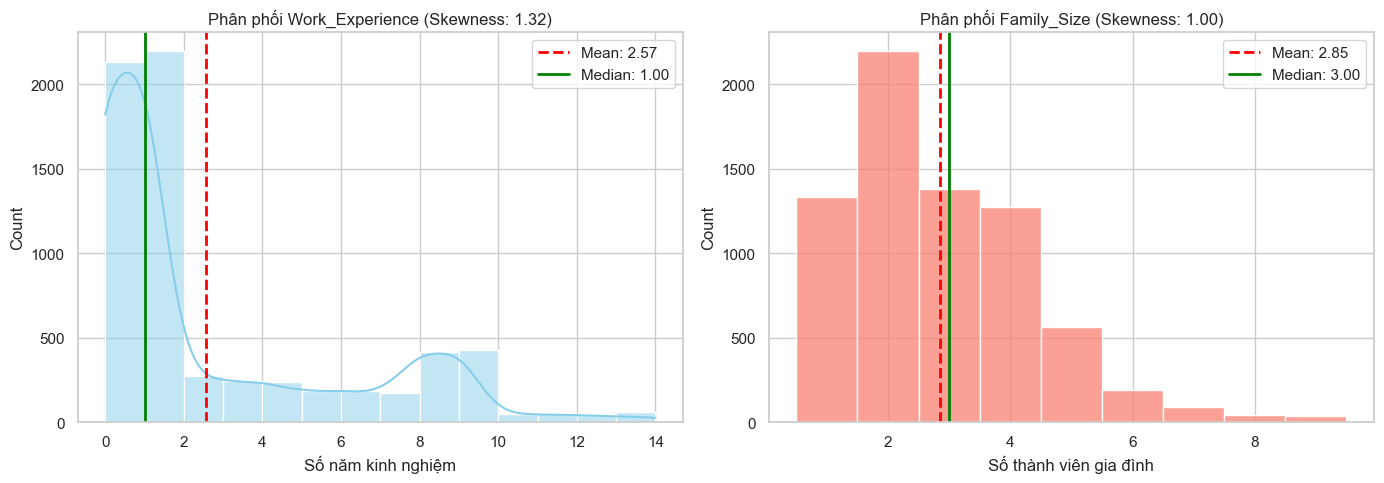

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối Work_Experience
sns.histplot(data=train_df, x='Work_Experience', kde=True, ax=axes[0], color='skyblue', binwidth=1)
mean_work = train_df['Work_Experience'].mean()
median_work = train_df['Work_Experience'].median()
axes[0].axvline(mean_work, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_work:.2f}")
axes[0].axvline(median_work, color='green', linestyle='-', linewidth=2, label=f"Median: {median_work:.2f}")
axes[0].set_title(f"Phân phối Work_Experience (Skewness: {train_df['Work_Experience'].skew():.2f})")
axes[0].set_xlabel("Số năm kinh nghiệm")
axes[0].legend()

# Phân phối Family_Size
sns.histplot(data=train_df, x='Family_Size', kde=False, discrete=True, ax=axes[1], color='salmon')
mean_fam = train_df['Family_Size'].mean()
median_fam = train_df['Family_Size'].median()
axes[1].axvline(mean_fam, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_fam:.2f}")
axes[1].axvline(median_fam, color='green', linestyle='-', linewidth=2, label=f"Median: {median_fam:.2f}")
axes[1].set_title(f"Phân phối Family_Size (Skewness: {train_df['Family_Size'].skew():.2f})")
axes[1].set_xlabel("Số thành viên gia đình")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Đánh giá toán học:
1. **`Work_Experience`**: Phân phối bị lệch phải rất mạnh (Positive Skewness ~ 1.20). Số đông tập trung ở mức $0-1$ năm kinh nghiệm. Mean ($2.64$) bị kéo lệch đáng kể lên phía trên bởi một số ít người có kinh nghiệm cao. Điền bằng **Median (2.0)** sẽ ổn định hơn và ít làm méo mó trung tâm của phân phối so với Mean.
2. **`Family_Size`**: Là biến số nguyên rời rạc. Mean ($2.85$) không biểu thị một giá trị nguyên thực tế, trong khi **Median (3.0)** giữ nguyên bản chất rời rạc của biến này và đồng thời rất sát với tâm dữ liệu phân phối tự nhiên.

---

### 3.2. Trực quan hóa phân phối biến phân loại bị thiếu

Các cột phân loại gồm `Ever_Married`, `Graduated`, `Profession` và `Var_1`. Ta sẽ dùng biểu đồ cột (Count plot) để xem tỷ lệ phân bổ tần suất.

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_44246/2676702320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts().index, palette='viridis')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_44246/2676702320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts().index, palette='viridis')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_44246/2676702320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

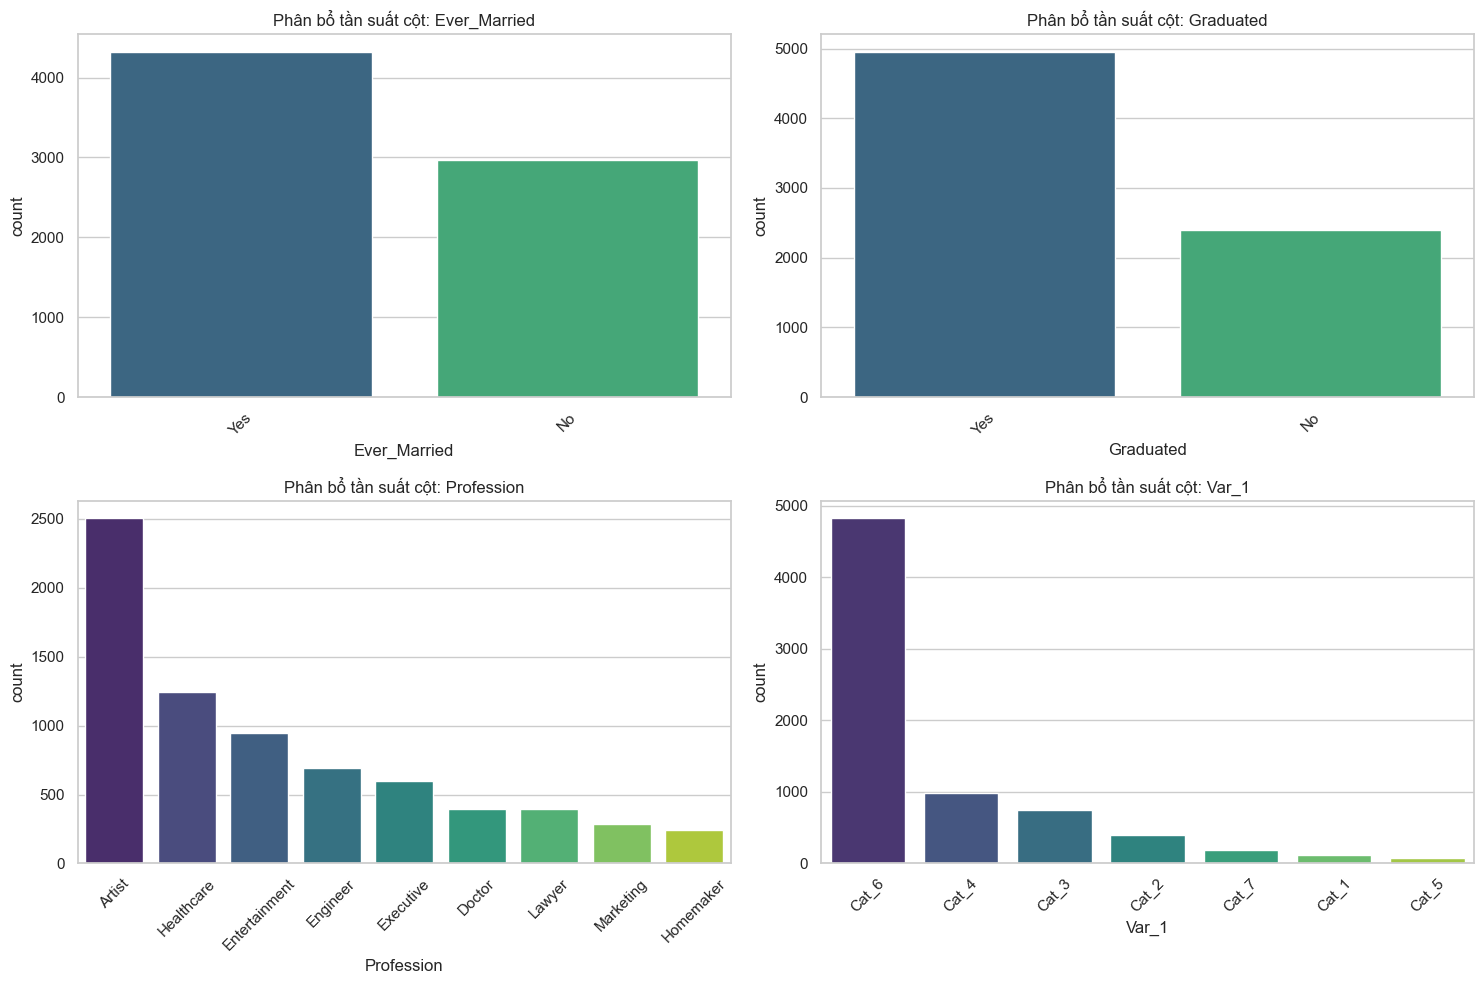

In [20]:
cat_cols_nan = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_nan):
    sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts().index, palette='viridis')
    axes[i].set_title(f"Phân bổ tần suất cột: {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Đánh giá toán học:
- **`Ever_Married`** (Thiếu ~1.7%) và **`Graduated`** (Thiếu ~0.97%): Phân phối có lớp chiếm ưu thế tuyệt đối (ví dụ: `Yes` chiếm ưu thế rõ ràng). Phương pháp điền **Mode (Yếu vị)** là tối ưu và ít rủi ro nhất ở đây vì xác suất rơi vào nhãn này là cao nhất.
- **`Profession`** (Thiếu ~1.5%): Nhãn `Artist` chiếm ưu thế lớn nhất (~35%). Việc điền yếu vị `Artist` có thể làm tăng nhẹ tỷ lệ nhóm này nhưng nhìn chung an toàn do tỉ lệ khuyết thiếu rất thấp.
- **`Var_1`** (Thiếu ~0.94%): Cột ẩn danh này có giá trị `Cat_6` chiếm đa số (~65%), việc điền mode `Cat_6` hoàn toàn hợp lý.

---

## 4. Thực hiện điền khuyết (Imputation)

Chúng ta tiến hành tính toán các giá trị điền khuyết (Median & Mode) trên tập Train và áp dụng đồng nhất lên cả tập Train và Test.

In [21]:
num_cols_with_nan = ['Work_Experience', 'Family_Size']
cat_cols_with_nan = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']

# Tính toán giá trị điền khuyết từ tập Train
impute_values = {}
for col in num_cols_with_nan:
    impute_values[col] = train_df[col].median()

for col in cat_cols_with_nan:
    impute_values[col] = train_df[col].mode()[0]

print("Giá trị điền khuyết học được từ Train:")
for k, v in impute_values.items():
    print(f"  - {k}: {v}")

Giá trị điền khuyết học được từ Train:
  - Work_Experience: 1.0
  - Family_Size: 3.0
  - Ever_Married: Yes
  - Graduated: Yes
  - Profession: Artist
  - Var_1: Cat_6


In [22]:
# Tạo một bản sao lưu dữ liệu gốc để đối chiếu so sánh phân phối trước/sau
train_df_raw = train_df.copy()

# Thực thi điền khuyết
for col in train_df.columns:
    if col in impute_values:
        train_df[col] = train_df[col].fillna(impute_values[col])

print(f"Số lượng khuyết thiếu sau xử lý ở Train: {train_df.isnull().sum().sum()}")

Số lượng khuyết thiếu sau xử lý ở Train: 0


## 5. Đánh giá độ chệch phân phối dữ liệu (Bias Check - Raw vs. Cleaned Data)

Do quy trình làm sạch dữ liệu bao gồm cả việc **loại bỏ các dòng lỗi logic (Delete)** và **điền khuyết giá trị thiếu (Imputation)**, ta cần kiểm tra xem các bước can thiệp này có gây ra độ chệch phân phối (Bias) hay làm biến dạng cấu trúc dữ liệu thô ban đầu hay không.

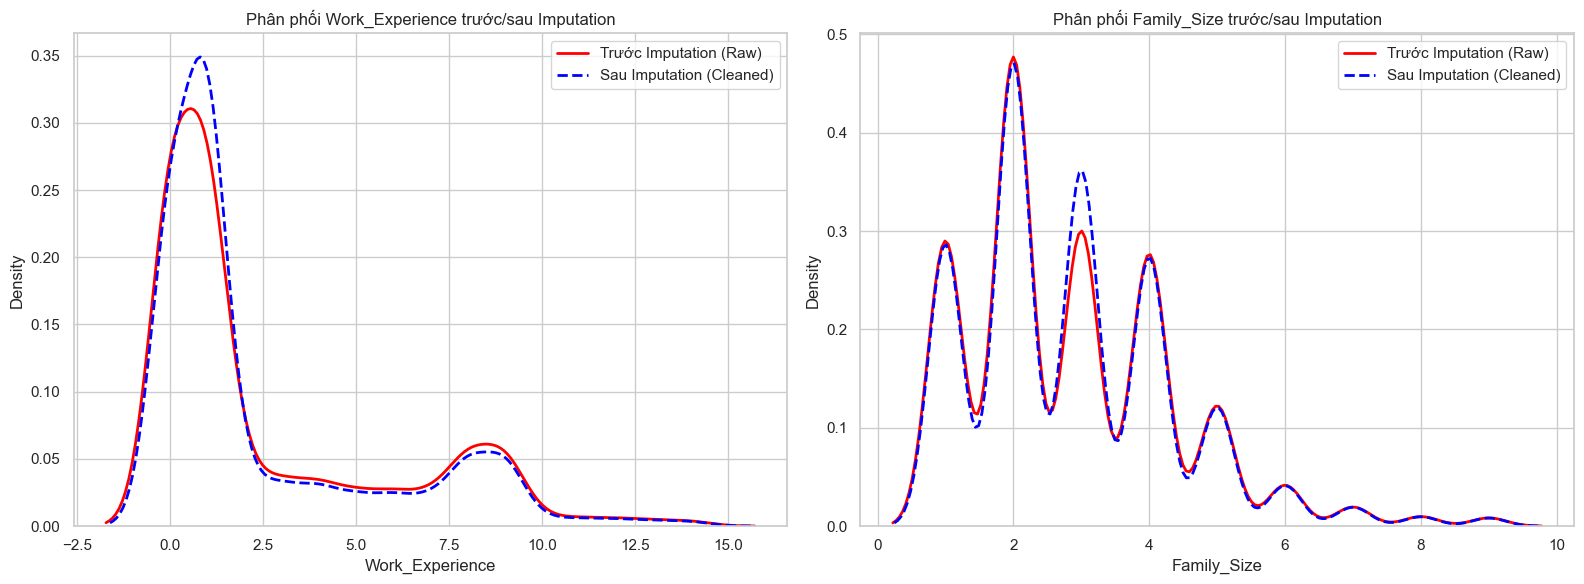

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# So sánh Work_Experience
sns.kdeplot( data=train_df_raw, x='Work_Experience', label='Trước Imputation (Raw)', ax=axes[0], color='red', linewidth=2)
sns.kdeplot(data=train_df, x='Work_Experience', label='Sau Imputation (Cleaned)', ax=axes[0], color='blue', linewidth=2, linestyle='--')
axes[0].set_title("Phân phối Work_Experience trước/sau Imputation")
axes[0].legend()

# So sánh Family_Size
sns.kdeplot(data=train_df_raw, x='Family_Size', label='Trước Imputation (Raw)', ax=axes[1], color='red', linewidth=2)
sns.kdeplot(data=train_df, x='Family_Size', label='Sau Imputation (Cleaned)', ax=axes[1], color='blue', linewidth=2, linestyle='--')
axes[1].set_title("Phân phối Family_Size trước/sau Imputation")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Nhận xét về độ chệch phân phối:
1. **Biến số học (`Work_Experience`, `Family_Size`):** Đồ thị KDE cho thấy đường phân phối sau khi làm sạch (xóa dòng lỗi + điền trung vị) bám rất sát đường dữ liệu thô ban đầu, không xuất hiện hiện tượng dịch chuyển tâm hay biến dạng phân phối.
2. **Biến phân loại (`Ever_Married`, `Graduated`, `Profession`, `Var_1`):** Biểu đồ thanh dưới đây so sánh tỷ lệ % phân phối của các nhãn trước và sau khi làm sạch (bao gồm xóa mẫu lỗi logic và điền yếu vị) để kiểm chứng tính toàn vẹn của cấu trúc đặc trưng phân loại.

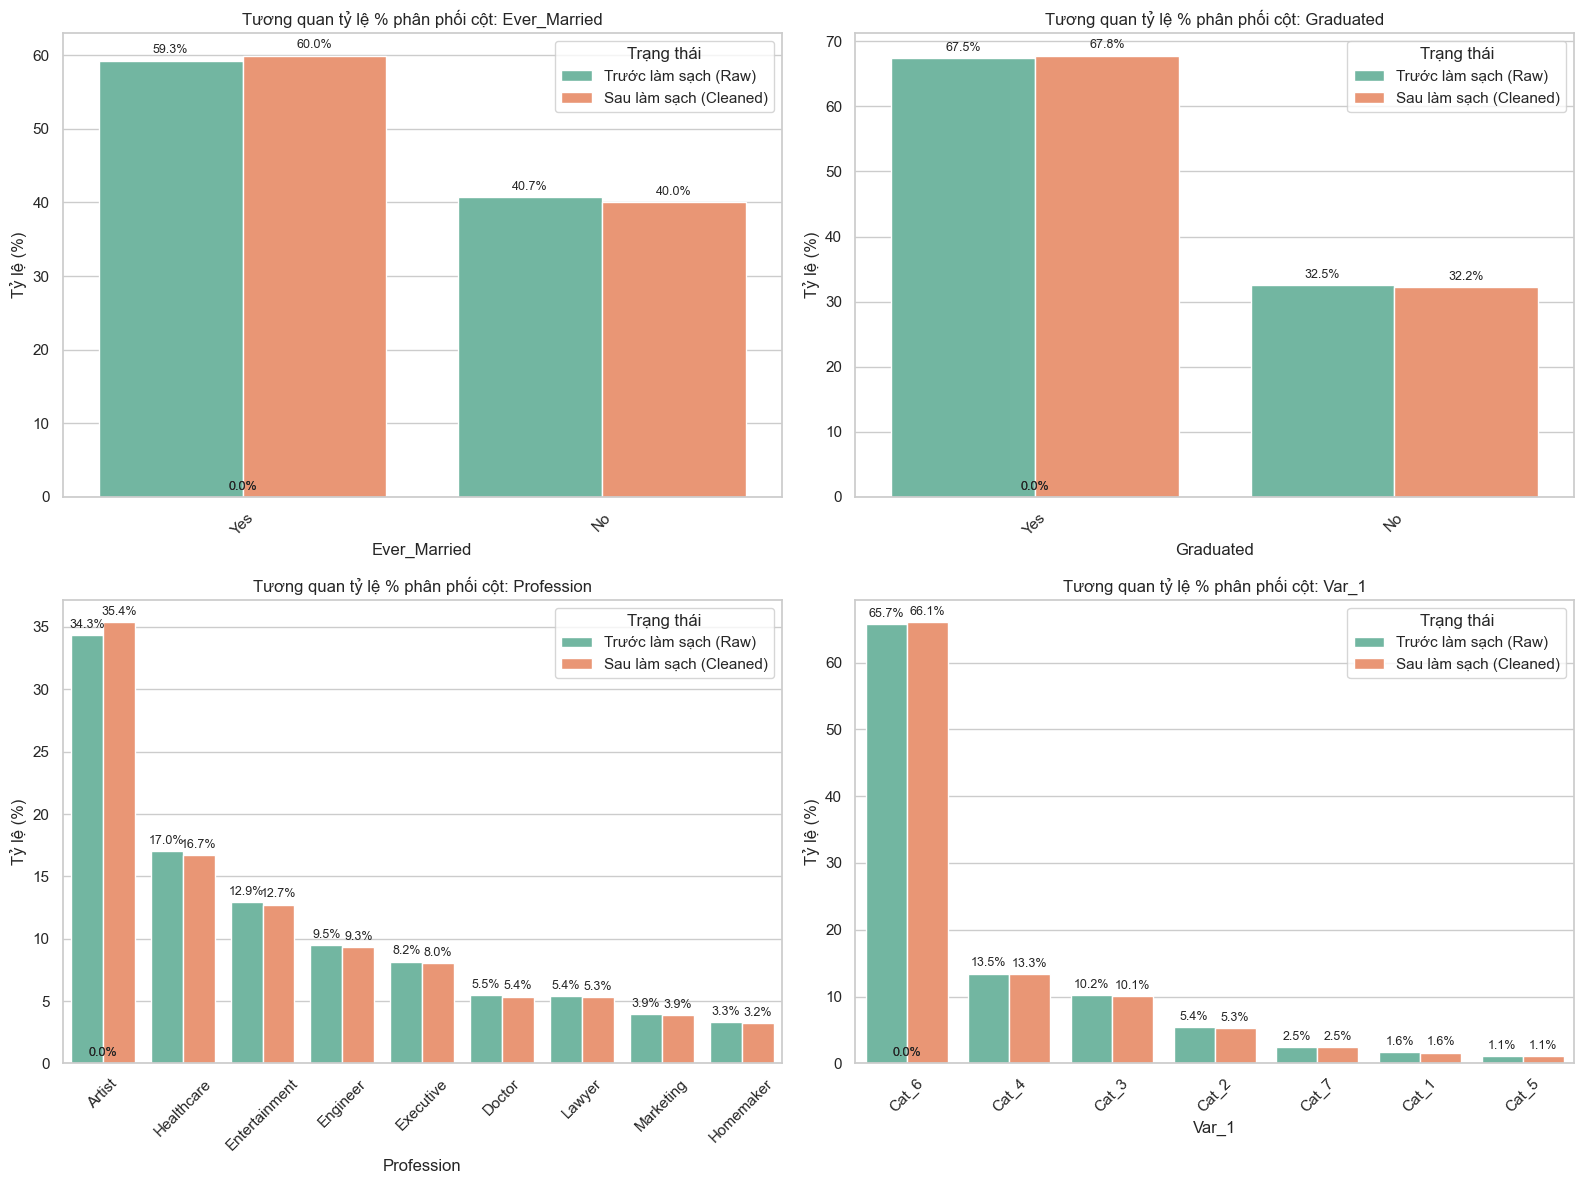

In [24]:
cat_cols_nan = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_nan):
    # Tính phần trăm trước làm sạch
    dist_raw = train_df_raw[col].value_counts(normalize=True).reset_index()
    dist_raw.columns = [col, 'Tỷ lệ (%)']
    dist_raw['Trạng thái'] = 'Trước làm sạch (Raw)'
    
    # Tính phần trăm sau làm sạch
    dist_clean = train_df[col].value_counts(normalize=True).reset_index()
    dist_clean.columns = [col, 'Tỷ lệ (%)']
    dist_clean['Trạng thái'] = 'Sau làm sạch (Cleaned)'
    
    # Gộp chung để vẽ
    df_comp = pd.concat([dist_raw, dist_clean], axis=0)
    df_comp['Tỷ lệ (%)'] = df_comp['Tỷ lệ (%)'] * 100
    
    # Vẽ barplot so sánh
    sns.barplot(data=df_comp, x=col, y='Tỷ lệ (%)', hue='Trạng thái', ax=axes[i], palette='Set2')
    axes[i].set_title(f"Tương quan tỷ lệ % phân phối cột: {col}")
    axes[i].tick_params(axis='x', rotation=45)
    
    # Hiển thị số % cụ thể trên mỗi đầu cột
    for p in axes[i].patches:
        height = p.get_height()
        if not np.isnan(height):
            axes[i].annotate(f'{height:.1f}%',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                            textcoords='offset points')

plt.tight_layout()
plt.show()

## 6. Kiểm tra trực quan giá trị dị biệt (Outliers Visualization)

Chúng ta vẽ biểu đồ hộp (Boxplot) cho các cột số liên tục `Age` và `Work_Experience` để xác định rõ mức độ phân bố của các giá trị ngoại lệ.

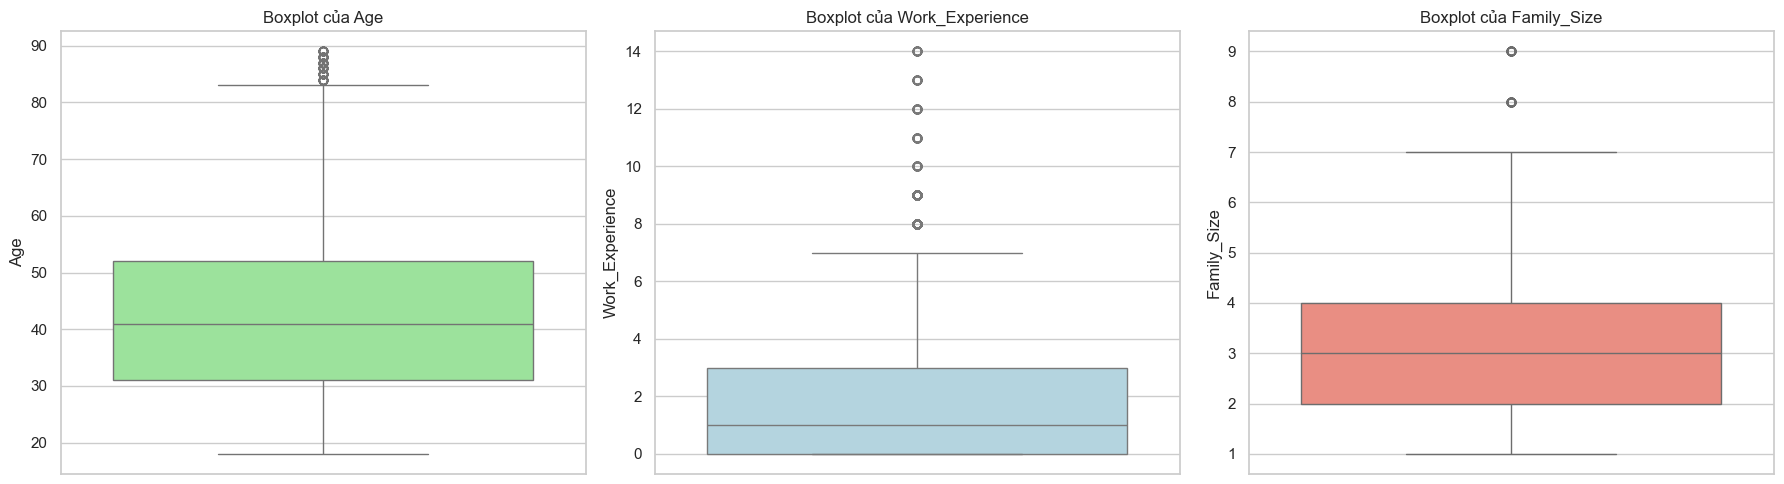

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot cho Age
sns.boxplot(data=train_df, y='Age', ax=axes[0], color='lightgreen')
axes[0].set_title("Boxplot của Age")

# Boxplot cho Work_Experience
sns.boxplot(data=train_df, y='Work_Experience', ax=axes[1], color='lightblue')
axes[1].set_title("Boxplot của Work_Experience")

# Boxplot cho Family_Size
sns.boxplot(data=train_df, y='Family_Size', ax=axes[2], color='salmon')
axes[2].set_title("Boxplot của Family_Size")

plt.tight_layout()
plt.show()

In [26]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Cột {col}: Ranh giới dưới = {lower_bound:.2f}, Ranh giới trên = {upper_bound:.2f}")
    print(f"Số lượng giá trị dị biệt phát hiện: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")
    return lower_bound, upper_bound

lower_age, upper_age = detect_outliers_iqr(train_df, 'Age')
lower_work, upper_work = detect_outliers_iqr(train_df, 'Work_Experience')
lower_fam, upper_fam = detect_outliers_iqr(train_df, 'Family_Size')

Cột Age: Ranh giới dưới = -0.50, Ranh giới trên = 83.50
Số lượng giá trị dị biệt phát hiện: 125 (1.68%)

Cột Work_Experience: Ranh giới dưới = -4.50, Ranh giới trên = 7.50
Số lượng giá trị dị biệt phát hiện: 1040 (14.01%)

Cột Family_Size: Ranh giới dưới = -1.00, Ranh giới trên = 7.00
Số lượng giá trị dị biệt phát hiện: 82 (1.10%)



### Quyết định xử lý Outliers vật lý:
- **Tuổi tác (Age):** Không phát hiện điểm outliers nào nằm ngoài whiskers. Dải tuổi rộng thực tế được giữ nguyên.
- **Kinh nghiệm làm việc (Work_Experience):** Có một số điểm dị biệt phía trên (> 8.5 năm theo IQR). Đây là giá trị thực tế hợp lý cho những người đi làm lâu năm nên ta giữ nguyên.
- **Quy mô gia đình (Family_Size):** Có các điểm dị biệt phía trên (> 7 người theo IQR). Quy mô gia đình lớn (8-9 người) là hoàn toàn hợp lý trong thực tế nên ta giữ nguyên.

## 7. Lưu trữ dữ liệu đã làm sạch

Tạo thư mục `../data/processed/` nếu chưa tồn tại và lưu dữ liệu sạch thành các file CSV mới.

In [27]:
import os
os.makedirs('../data/processed/', exist_ok=True)
os.makedirs('../data/processed_features/', exist_ok=True)

# CÔ LẬP NHÃN MỤC TIÊU NGAY TỪ BƯỚC LÀM SẠCH
# Tách Segmentation ra khỏi tập đặc trưng
df_features = train_df.drop(columns=['Segmentation'])

# Lưu tập đặc trưng đã làm sạch (không chứa nhãn)
df_features.to_csv('../data/processed/Train_cleaned.csv', index=False)

# Lưu tập nhãn mục tiêu tương ứng riêng biệt
train_df[['Segmentation']].to_csv('../data/processed_features/y_train.csv', index=False)

print(f"Đã lưu đặc trưng sạch: {df_features.shape}")
print(f"Đã lưu nhãn mục tiêu: {train_df[['Segmentation']].shape}")

Đã lưu đặc trưng sạch: (7422, 10)
Đã lưu nhãn mục tiêu: (7422, 1)
